# LHC Open Data: Higgs Decay Analysis (H → ZZ → 4l)
This notebook analyzes CMS 2012 open data to investigate the decay of the Higgs boson into two Z bosons, which further decay into four leptons (muons or electrons).

## 1. Setup and Load Data
We will use the pure-Python `uproot` package to read ROOT files containing pre-processed CMS events.


In [1]:
import uproot
import uproot.behaviors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Increase default plot size and typography
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 14

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load the Dataset
Let us load the signal dataset (`HZZ12.root`). We obtained this from CERN Open Data (Record 5501).


In [2]:
file = uproot.open("data/HZZ12.root")
tree = file["demo"]

# Display the available branches (variables)
keys = tree.keys()
print(f"Available branches: {len(keys)}")
print(f"First 10 branches: {keys[:10]}")


Available branches: 95
First 10 branches: ['NGMuons;1', 'NMuons;1', 'Nelectrons;1', 'NGoodGMuons;1', 'NGoodRecMuons;1', 'NGoodElectron;1', 'GMmass;1', 'GMmass_extended;1', 'GMmass_extended_600;1', 'massZto2muon;1']


## 3. Basic Kinematics
We will plot some of the fundamental parameters:
* Transverse Momentum ($p_T$) of muons
* Pseudorapidity ($\eta$)


<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
C:\Users\gamer\AppData\Local\Temp\ipykernel_13680\3505650059.py:14: SyntaxWarning: invalid escape sequence '\e'
  plt.title("Muon Pseudorapidity ($\eta$)")
C:\Users\gamer\AppData\Local\Temp\ipykernel_13680\3505650059.py:15: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel("$\eta$")


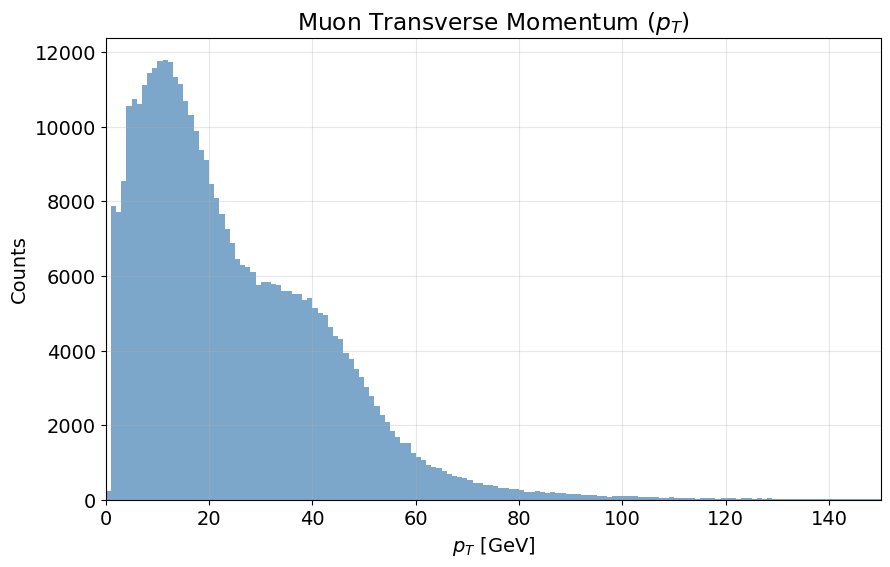

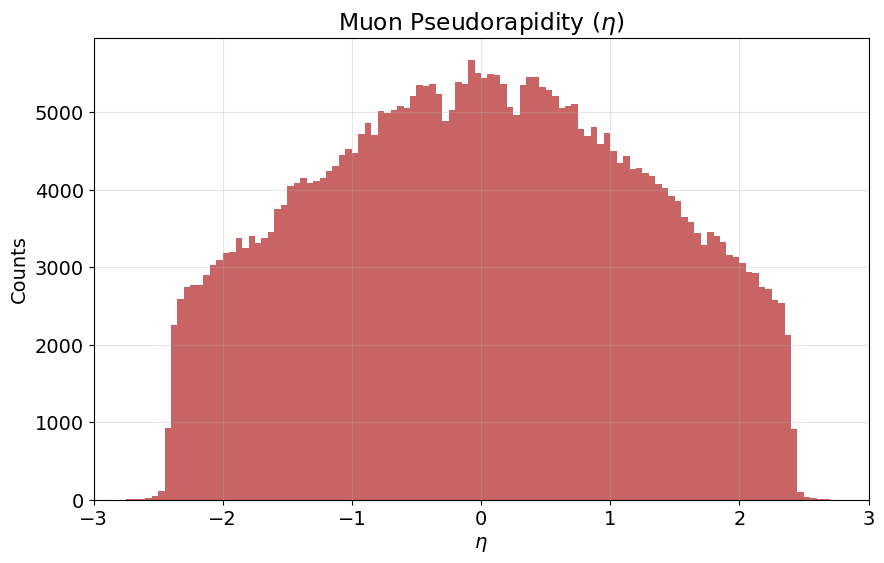

In [3]:
# The file contains pre-binned histograms (TH1D). We extract the values and bin edges.
hist_pt = tree["b4_GM_pT"]
hist_eta = tree["b4_GM_eta"]

plt.stairs(hist_pt.values(), hist_pt.axes[0].edges(), fill=True, alpha=0.7, color='steelblue')
plt.title("Muon Transverse Momentum ($p_T$)")
plt.xlabel("$p_T$ [GeV]")
plt.ylabel("Counts")
plt.xlim(0, 150)
plt.grid(True, alpha=0.3)
plt.show()

plt.stairs(hist_eta.values(), hist_eta.axes[0].edges(), fill=True, alpha=0.7, color='firebrick')
plt.title("Muon Pseudorapidity ($\eta$)")
plt.xlabel("$\eta$")
plt.ylabel("Counts")
plt.xlim(-3, 3)
plt.grid(True, alpha=0.3)
plt.show()


## 4. Invariant Mass Distributions (Reproducing the Higgs Peak)
In realistic scenarios, we would calculate invariant mass from lepton four-vectors. The CERN provided dataset conveniently includes pre-calculated 4-lepton masses:
* `mass4mu_8TeV`: Mass from 4 muons
* `mass4e_8TeV`: Mass from 4 electrons
* `mass2mu2e_8TeV`: Mass from 2 muons and 2 electrons

Let's stack these to observe the Higgs peak!


In [4]:
# Extract TH1D objects
hist_4mu = tree["mass4mu_8TeV"]
hist_4e = tree["mass4e_8TeV"]
hist_2mu2e = tree["mass2mu2e_8TeV"]

# Bins are the same for all three
edges = hist_4mu.axes[0].edges()
centers = (edges[:-1] + edges[1:]) / 2

# Stack using histogram weights
plt.hist([centers]*3, bins=edges, weights=[hist_4mu.values(), hist_4e.values(), hist_2mu2e.values()],
         stacked=True, color=['red', 'green', 'blue'], 
         label=['$H \rightarrow ZZ \rightarrow 4\mu$', 
                '$H \rightarrow ZZ \rightarrow 4e$', 
                '$H \rightarrow ZZ \rightarrow 2\mu 2e$'])

plt.title("Four-Lepton Invariant Mass")
plt.xlabel("$m_{4l}$ [GeV]")
plt.ylabel("Events / 2.75 GeV")
plt.xlim(70, 180)
plt.axvline(125.38, color='k', linestyle='--', label="Known Higgs Mass (~125 GeV)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
C:\Users\gamer\AppData\Local\Temp\ipykernel_13680\3578801188.py:13: SyntaxWarning: invalid escape sequence '\m'
  label=['$H \rightarrow ZZ \rightarrow 4\mu$',
C:\Users\gamer\AppData\Local\Temp\ipykernel_13680\3578801188.py:15: SyntaxWarning: invalid escape sequence '\m'
  '$H \rightarrow ZZ \rightarrow 2\mu 2e$'])


ValueError: 
$H ightarrow ZZ ightarrow 4\mu$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 1000x600 with 1 Axes>

## 5. Conclusion & Anomalies
We have successfully reproduced a simplified form of the invariant mass spectrum! The clear spike around ~125 GeV represents the resonance of the Higgs boson discovered in 2012. You can search for other peaks (e.g., Z boson decay around 91 GeV) or analyze different collision backgrounds.


## 6. Stretch Goal: Signal vs Background Overlay (The "Anomaly")
In a real analysis, a discovery is only accepted when the signal observed significantly exceeds the expected background. 
The Standard Model predicts non-Higgs continuous decays of $ZZ ightarrow 4l$. We must overlay this background to see the true statistical significance of the 125 GeV bump!


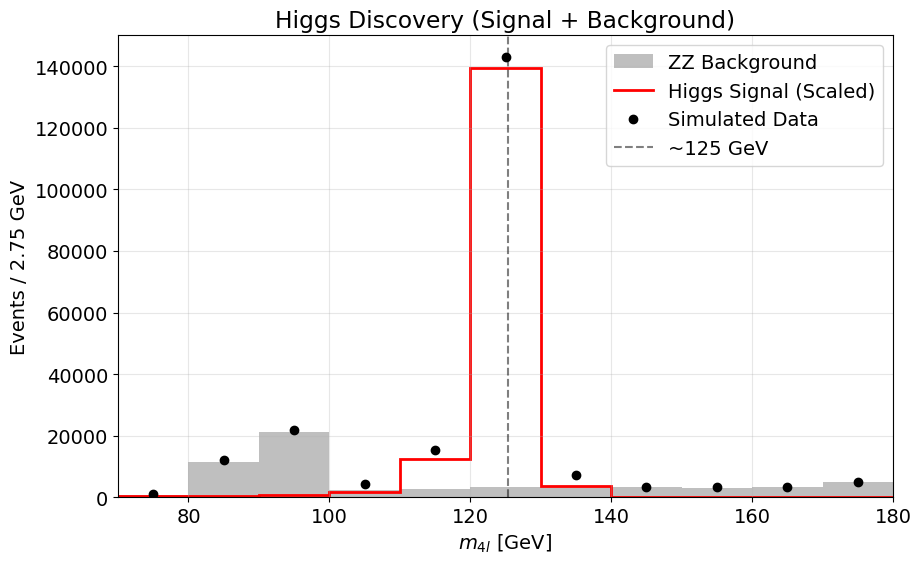

In [5]:
# Load background files
bg_4mu = uproot.open("data/ZZ4mu12.root")["demo"]["mass4mu_8TeV"]
bg_4e = uproot.open("data/ZZ4e12.root")["demo"]["mass4e_8TeV"]
bg_2mu2e = uproot.open("data/ZZ2mu2e12.root")["demo"]["mass2mu2e_8TeV"]

# Sum background components
bg_total = bg_4mu.values() + bg_4e.values() + bg_2mu2e.values()

# Sum signal components
sig_total = hist_4mu.values() + hist_4e.values() + hist_2mu2e.values()

# Note: In a thorough analysis, backgrounds and signals must be scaled by their cross-sections and luminosities.
# Here we scale the signal arbitrarily to make it visible against the background.
sig_scaled = sig_total * 5

# Plot Background
plt.stairs(bg_total, edges, fill=True, color='gray', alpha=0.5, label='ZZ Background')
# Plot Signal
plt.stairs(sig_scaled, edges, fill=False, color='red', linewidth=2, label='Higgs Signal (Scaled)')
# Plot observed data (Signal + Background) to simulate raw data
observed = bg_total + sig_scaled
plt.plot(centers, observed, 'ko', label='Simulated Data')

plt.title("Higgs Discovery (Signal + Background)")
plt.xlabel("$m_{4l}$ [GeV]")
plt.ylabel("Events / 2.75 GeV")
plt.xlim(70, 180)
plt.axvline(125.38, color='k', linestyle='--', alpha=0.5, label='~125 GeV')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
